文档被成功切分为 55 个块。

--- 第一个文章块示例 ---
元数据 (Metadata): {'header2': '1. [王清宪主持召开省政府第63次常务会议_安徽省人民政府](https://www.ah.gov.cn/public/1681/565403191.html)', 'id': 2, 'title': '王清宪主持召开省政府第63次常务会议_安徽省人民政府', 'source_url': 'https://www.ah.gov.cn/public/1681/565403191.html'}

内容 (Page Content):
## 1. [王清宪主持召开省政府第63次常务会议_安徽省人民政府](https://www.ah.gov.cn/public/1681/565403191.html)  
首页 > 政务公开 >安徽省人民政府办公厅 > 省政府会议
索引号：00298627-2/202502-00020信息分类：省政府会议
发布机构：安徽省人民政府办公厅生成日期：2025/02/22
名称：王清宪主持召开省政府第63次常务会议
文号：关 键 词：
王清宪主持召开省政府第63次常务会议
来源：安徽日报  
2月19日，省长王清宪主持召开省政府第63次常务会议，传达学习习近平总书记在民营企业座谈会上的重要讲话精神；深入贯彻习近平生态文明思想，审议《安徽省贯彻落实第三轮中央生态环境保护督察报告整改方案》等。  
会议强调，要把思想和行动统一到习近平总书记在民营企业座谈会上的重要讲话精神上来，落实省委要求，结合安徽实际，毫不动摇鼓励、支持、引导非公有制经济发展。要持续营造有利于民营经济发展的良好环境，一视同仁对待各类企业，保证各种所有制经济依法平等使用生产要素、公平参与市场竞争、同等受到法律保护。要倾心倾力为...


--- 第四个文章块示例 (政府批复) ---
元数据 (Metadata): {'header2': '4. [安徽省人民政府关于G36宁洛高速公路来安至明光段张八岭互通设站收费经营的批复_安徽省人民政府](https://www.ah.gov.cn/public/1681/565433081.html)', 'id': 5, 'title': '安徽省人民政府关于G36宁洛高速公路来安至明光段张八岭互通设站收费经营的批
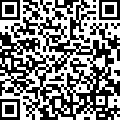

In [1]:
# 首先，请确保你已经安装了必要的库
from langchain_text_splitters import MarkdownHeaderTextSplitter
import re

file_path = '2025-07-12.md'

# 读取Markdown文件内容
with open(file_path, 'r', encoding='utf-8') as f:
    markdown_content = f.read()

# 定义我们希望用来切分的标题级别
# 在这个文档中，每篇文章都以 '##' (header 2) 开始
headers_to_split_on = [
    ("##", "header2")
]

# 实例化 MarkdownHeaderTextSplitter
markdown_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on,
    strip_headers=False # 我们保留标题在内容中，因为它包含有用的信息
)

# 执行切分
# split_text 方法返回一个 Document 对象的列表
# 每个 Document 包含 page_content 和 metadata
docs = markdown_splitter.split_text(markdown_content)

# --- 后处理：提取URL和纯文本标题到元数据中 ---
# 我们可以进一步处理元数据，使其更易于使用
for idx, doc in enumerate(docs, start=1):
    doc.metadata['id'] = idx  # 添加一个唯一的ID
    header2_value = doc.metadata.get("header2", "")
    if header2_value:
        # 使用正则表达式从 '## 1. [标题](URL)' 格式中提取标题和URL
        match = re.search(r'\[(.*?)\]\((.*?)\)', header2_value)
        if match:
            doc.metadata['title'] = match.group(1).strip()
            doc.metadata['source_url'] = match.group(2).strip()

# --- 打印结果，检查切分效果 ---

print(f"文档被成功切分为 {len(docs)} 个块。\n")

# 打印第一篇文章的切分结果作为示例
if len(docs) > 1:
    # 第一个块通常是文档的引言部分，我们看第二个块（即第一篇文章）
    first_article = docs[1]
    print("--- 第一个文章块示例 ---")
    print(f"元数据 (Metadata): {first_article.metadata}")
    print("\n内容 (Page Content):")
    # 为了简洁，只打印内容的前500个字符
    print(first_article.page_content[:500] + "...")
else:
    print("切分后的文档块不足，请检查文件内容和切分逻辑。")

# 打印第四篇文章（政府批复，结构简单）的切分结果
if len(docs) > 4:
    fourth_article = docs[4]
    print("\n\n--- 第四个文章块示例 (政府批复) ---")
    print(f"元数据 (Metadata): {fourth_article.metadata}")
    print("\n内容 (Page Content):")
    print(fourth_article.page_content)



In [2]:
import torch
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import os

CHROMA_DB_PATH = './chroma_db'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# 最开始使用shibing624/text2vec-base-multilingual，检索效果非常差
# sentence_transform_embeddings = HuggingFaceEmbeddings(model_name='shibing624/text2vec-base-multilingual')
# sentence_transform_embeddings = HuggingFaceEmbeddings(
#     model_name='BAAI/bge-m3',
#     model_kwargs={'device': 'cuda'},
#     encode_kwargs={'normalize_embeddings': True} # BGE 模型推荐进行归一化
# )
sentence_transform_embeddings = HuggingFaceEmbeddings(
    model_name='BAAI/bge-base-zh-v1.5',
    model_kwargs={'device': device},
    encode_kwargs={'normalize_embeddings': True} # BGE 模型推荐进行归一化
)
# 判断是否存在持久化文件，存在则直接加载

vectorstore = None
if os.path.exists(CHROMA_DB_PATH):
    # 如果目录存在，则直接加载
    print(f"发现已存在的数据库 '{CHROMA_DB_PATH}'，正在加载...")
    vectorstore = Chroma(
        persist_directory=CHROMA_DB_PATH,
        embedding_function=sentence_transform_embeddings
    )
    print("数据库加载成功！")
else:
    # 如果目录不存在，则创建并持久化
    print(f"未发现数据库，正在从文档创建新的数据库并持久化到 '{CHROMA_DB_PATH}'...")
    vectorstore = Chroma.from_documents(
        documents=docs,
        embedding=sentence_transform_embeddings,
        persist_directory=CHROMA_DB_PATH
    )
    print("数据库创建并持久化成功！")

# 创建 Chroma向量 检索器
chroma_retriever = vectorstore.as_retriever(search_type="similarity", k=10)

D:\Python\PythonProject\openai-quickstart\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


未发现数据库，正在从文档创建新的数据库并持久化到 './chroma_db'...
数据库创建并持久化成功！


In [3]:
from langchain.retrievers import BM25Retriever, EnsembleRetriever
# 创建 BM25 检索器
bm25_retriever = BM25Retriever.from_documents(documents=docs, k=10)
# 创建一个集成检索器，将 BM25 检索器与向量存储结合
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, chroma_retriever]
)

shibing624/text2vec-base-multilingual向量检索器完全是副作用，BAAI/bge-m3跑不起来，BAAI/bge-base-zh-v1.5效果很好

In [4]:
# 测试检索器
# 定义要测试的查询列表
querys = [
    "国防动员包含哪些内容？",
    "安徽省加快构建“政产学研金服用”有什么举措？",
    "2025年“活力中国调研行”媒体见面会讲了啥？",
    "对于公民的国防义务，法律是怎么规定的？" # 增加一个语义更模糊的查询
]

# 遍历每个查询
for query in querys:
    print("\n" + "="*80)
    print(f"【查询】: '{query}'")
    print("="*80)

    # --- 1. 使用 Chroma (向量) 检索器 ---
    print("\n--- (1) Chroma (向量) 检索结果 ---")
    # 使用 .invoke() 方法来执行检索
    chroma_search_results = chroma_retriever.invoke(query)
    if chroma_search_results:
        for i, doc in enumerate(chroma_search_results[:3]): # 只显示前3个结果以便比较
            print(f"  [结果 {i+1}] 标题: {doc.metadata.get('title', 'N/A')}")
            print(f"           内容: {doc.page_content[:150].strip().replace(chr(10), ' ')}...")
    else:
        print("  未找到相关结果。")


    # --- 2. 使用 BM25 (关键词) 检索器 ---
    print("\n--- (2) BM25 (关键词) 检索结果 ---")
    # 使用 .invoke() 方法来执行检索
    bm25_search_results = bm25_retriever.invoke(query)
    if bm25_search_results:
        for i, doc in enumerate(bm25_search_results[:3]): # 只显示前3个结果
            print(f"  [结果 {i+1}] 标题: {doc.metadata.get('title', 'N/A')}")
            print(f"           内容: {doc.page_content[:150].strip().replace(chr(10), ' ')}...")
    else:
        print("  未找到相关结果。")


    # --- 3. 使用 Ensemble (混合) 检索器 ---
    print("\n--- (3) Ensemble (混合) 检索结果 ---")
    # 使用 .invoke() 方法来执行检索
    ensemble_search_results = ensemble_retriever.invoke(query)
    if ensemble_search_results:
        for i, doc in enumerate(ensemble_search_results[:3]): # 只显示前3个结果
            print(f"  [结果 {i+1}] 标题: {doc.metadata.get('title', 'N/A')}")
            print(f"           内容: {doc.page_content[:150].strip().replace(chr(10), ' ')}...")
    else:
        print("  未找到相关结果。")

print("\n" + "="*80)
print("所有查询测试完成！")



【查询】: '国防动员包含哪些内容？'

--- (1) Chroma (向量) 检索结果 ---
  [结果 1] 标题: 在新时代新征程上谱写安徽国防动员建设新篇章_安徽省人民政府
           内容: ## 2. [在新时代新征程上谱写安徽国防动员建设新篇章_安徽省人民政府](https://www.ah.gov.cn/zmhd/zxft/564292701.html)   首页 > 互动交流 > 在线访谈 访谈实录 在新时代新征程上谱写安徽国防动员建设新篇章 嘉宾： 王万顺 省国防动员办公室党组...
  [结果 2] 标题: 2025年全省防汛抗旱工作情况新闻发布会_安徽省人民政府
           内容: ## 40. [2025年全省防汛抗旱工作情况新闻发布会_安徽省人民政府](https://www.ah.gov.cn/zmhd/xwfbhx/565432421.html)   首页 > 互动交流 > 新闻发布会 2025年全省防汛抗旱工作情况新闻发布会   发布人： 省应急管理厅副厅长白中华，省...
  [结果 3] 标题: 深入贯彻落实《住房城乡建设部关于推进城市基础设施生命线安全工程的指导意见》_安徽省人民政府
           内容: ## 6. [深入贯彻落实《住房城乡建设部关于推进城市基础设施生命线安全工程的指导意见》_安徽省人民政府](https://www.ah.gov.cn/zmhd/zxft/564288561.html)   首页 > 互动交流 > 在线访谈 访谈实录 深入贯彻落实《住房城乡建设部关于推进城市基础设施...

--- (2) BM25 (关键词) 检索结果 ---
  [结果 1] 标题: 安徽省人民政府办公厅关于印发《安徽省“高效办成一件事”2025年度第一批拓展重点事项清单》的通知_安徽省人民政府
           内容: ## 54. [安徽省人民政府办公厅关于印发《安徽省“高效办成一件事”2025年度第一批拓展重点事项清单》的通知_安徽省人民政府](https://www.ah.gov.cn/public/1681/565420661.html)   首页 > 政务公开 >安徽省人民政府办公厅 > 政策法规 > 省...
  [结果 2] 标题: 王清宪主持召开省政府第67次常务会

自定义提示词模板

In [9]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os

load_dotenv()
if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GEMINI_API_KEY not found in .env file or environment variables.")
print("Gemini API Key loaded successfully.")
prompt_template = """你是一个严谨的AI助手，你的任务是根据提供的上下文信息准确回答用户的问题。

请遵循以下规则：
1.  仔细阅读并理解下面由 <context> 标签包裹的参考资料。
2.  你的回答必须完全基于这些参考资料，不得添加任何外部知识或个人猜测。
3.  在回答问题的结尾，你必须用 "来源：" 格式列出你参考的所有文档的标题。文档标题在每段资料的开头以 "文档标题:" 形式提供。
4.  如果参考资料无法回答问题，请直接说：“我没有在提供的资料中找到相关信息。”

<context>
{context}
</context>

<question>
{question}
</question>

请给出你的回答：
"""
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=prompt_template
)

llm = ChatGoogleGenerativeAI(model="gemini-2.5-pro")

def format_documents(docs):
    """格式化文档列表为字符串"""
    return "\n\n---\n\n".join([f"文档标题: {doc.metadata.get('title', '无标题')}\n内容: {doc.page_content}" for doc in docs])

rag_chain = (
    RunnableParallel(
        context=ensemble_retriever | format_documents,
        question=RunnablePassthrough()  # 直接传递用户问题
    )
    | prompt
    | llm
    | StrOutputParser()
)

Gemini API Key loaded successfully.


In [10]:
rag_chain.invoke(querys[0])

'根据提供的资料，国防动员是国家统一调配使用资源，将国防潜力转化为国防实力，用于应对战争和其他安全威胁，以及服务经济社会发展的活动。国家的人力、物力、财力，乃至所有可用于战争的物质和力量都是动员的内容。按照工作内容，一般分为以下6大类：\n\n1.  **政治动员**：为应对战争、突发事件和紧急状态需要，有计划、有组织地对人民群众和军队进行的思想发动、政治宣传、精神灌注，以及在国内建立广泛的爱国统一战线，在国外争取国际支持的一系列活动。\n2.  **武装力量动员**：国家为适应战争或其他重大突发事件的需要，扩充和调整军队及其他武装组织由平时状态转入战时状态所进行的活动，是国防动员的核心。通常包括常备力量动员和后备力量动员。\n3.  **国民经济动员**：国家为了应对战争和突发事件的需要，有计划、有组织地将国民经济及其相应的体制，由平时状态转入战时、急时状态所进行的活动。包括工业、农业、商业贸易、财政金融、邮电通信、科学技术、医药卫生及其他动员。\n4.  **人民防空动员**：国家为了保障人民群众的生命和财产安全而组织和进行的防备敌人空袭、消除空袭后果等一系列活动。\n5.  **交通运输动员**：国家为实施战争或应对其他安全威胁的需要，组织调动交通运输设施、设备、工具和交通运输专业技术保障力量等资源的活动。\n6.  **新兴领域动员**：国家通过对新兴领域各种产业、技术和资源的统筹利用，为战时提供支援保障。主要包括太空、极地、深海、网络、生物、认知、无人、智能等新域新质力量。\n\n来源：在新时代新征程上谱写安徽国防动员建设新篇章_安徽省人民政府'

In [12]:
from langchain import hub
hub_prompt = hub.pull("rlm/rag-prompt")
print(hub_prompt)

hub_rag_chain = (
    RunnableParallel(
        context=ensemble_retriever | format_documents,
        question=RunnablePassthrough()  # 直接传递用户问题
    )
    | hub_prompt
    | llm
    | StrOutputParser()
)

D:\Python\PythonProject\openai-quickstart\.venv\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]


In [13]:
hub_rag_chain.invoke(querys[0])

'根据文件内容，国防动员包含国家的人力、物力、财力等所有可用于战争的物质和力量。按照工作内容，一般可分为六大类。这六类分别是政治动员、武装力量动员、国民经济动员、人民防空动员、交通运输动员和新兴领域动员。'